<a href="https://colab.research.google.com/github/pavan-ka/CS-4650-Final-Project/blob/main/Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Enron pipeline — **standalone** Colab (no GitHub)

All project code (`src/`, `configs/`) is **embedded** in this notebook and written to `/content/enron_pipeline` when you run the bootstrap cell.

**Data:** Kaggle API (recommended) or `GOOGLE_DRIVE_URL` — same as the repo’s `download_data` module.

**Order:** run cells **top to bottom**. Use a **GPU** runtime for faster training.


## 1. Install dependencies

In [ ]:
!pip install -q --upgrade pip
!pip install -q datasets matplotlib numpy pandas pyyaml scikit-learn scipy seaborn shap spacy torch transformers tqdm kaggle gdown
!pip install -q --upgrade "transformers==4.46.3" "datasets==2.21.0" "accelerate>=0.33.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


## 2. spaCy model (for person masking in preprocess)

In [ ]:
!python -m spacy download en_core_web_lg


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 33.4 MB/s  0:00:09
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 3. Kaggle credentials

Use Colab **Secrets** (`KAGGLE_USERNAME`, `KAGGLE_KEY`) or upload `kaggle.json` to `/root/.kaggle/kaggle.json`.

In [ ]:
from pathlib import Path
import json
import os
import stat

# set up kaggle directory
kaggle_path = Path("/root/.kaggle")
kaggle_path.mkdir(exist_ok=True, parents=True)
config_file = kaggle_path / "kaggle.json"

try:
    # try grabbing creds from Colab secrets
    from google.colab import userdata
    username = userdata.get("KAGGLE_USERNAME")
    key = userdata.get("KAGGLE_KEY")

    config_file.write_text(json.dumps({
        "username": username,
        "key": key
    }))
    print("Wrote Kaggle credentials from Colab secrets.")

except Exception as err:
    print("Couldn't use Colab secrets:", err)
    if config_file.exists():
        print(f"Found existing credentials at {config_file}")
    else:
        print("No credentials found. Upload kaggle.json or set secrets.")

# set permissions + env vars if file exists
if config_file.exists():
    config_file.chmod(stat.S_IRUSR | stat.S_IWUSR)

    with open(config_file) as f:
        creds = json.load(f)

    os.environ["KAGGLE_USERNAME"] = creds.get("username")
    os.environ["KAGGLE_KEY"] = creds.get("key")

    print("Kaggle environment variables set.")

Wrote Kaggle credentials from Colab Secrets.
Kaggle env set.


In [ ]:
import os
os.environ.setdefault("GOOGLE_DRIVE_URL", "")
print("GOOGLE_DRIVE_URL:", os.environ.get("GOOGLE_DRIVE_URL") or "(empty)")


GOOGLE_DRIVE_URL: (empty)


## 5. Bootstrap: write `src/` and `configs/` from the notebook

Writes out all necessary files for training

In [ ]:
#Set up project root and Python path
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path("/content/enron_pipeline")
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Current working directory:", os.getcwd())


In [ ]:
#Create folders
from pathlib import Path

DIRS = ['configs', 'src', 'src/data', 'src/utils', 'data/raw', 'data/processed', 'data/splits', 'outputs/models', 'outputs/metrics', 'outputs/figures', 'outputs/logs/slurm']

for folder in DIRS:
    Path(folder).mkdir(parents=True, exist_ok=True)

print(f"Created {len(DIRS)} folders")


In [ ]:
#marks src as the main project package
%%writefile src/__init__.py
"""Enron role prediction package."""

In [ ]:
#marks utils as the helper utilities package
%%writefile src/utils/__init__.py
"""Shared utility helpers."""


In [ ]:
#handles folder creation and yaml config loading
%%writefile src/utils/io.py
from __future__ import annotations

from pathlib import Path
from typing import Any, Dict

import yaml


def ensure_dir(path: str | Path) -> Path:
    directory = Path(path)
    directory.mkdir(parents=True, exist_ok=True)
    return directory


def load_yaml(path: str | Path) -> Dict[str, Any]:
    with Path(path).open("r", encoding="utf-8") as handle:
        return yaml.safe_load(handle)


In [ ]:
#creates reusable console and file loggers
%%writefile src/utils/logging.py
from __future__ import annotations

import logging
from pathlib import Path


def configure_logger(name: str, log_file: str | None = None) -> logging.Logger:
    logger = logging.getLogger(name)
    if logger.handlers:
        return logger

    logger.setLevel(logging.INFO)
    formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(name)s | %(message)s")

    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)
    logger.addHandler(stream_handler)

    if log_file:
        Path(log_file).parent.mkdir(parents=True, exist_ok=True)
        file_handler = logging.FileHandler(log_file)
        file_handler.setFormatter(formatter)
        logger.addHandler(file_handler)

    return logger


In [ ]:
#sets random seeds for reproducible model runs
%%writefile src/utils/seeding.py
from __future__ import annotations

import os
import random

import numpy as np
import torch


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


In [ ]:
#marks data as the data processing package
%%writefile src/data/__init__.py
"""Data processing modules."""


In [ ]:
#downloads enron datasets from kaggle
%%writefile src/data/download_data.py
from __future__ import annotations

import argparse
import email
import inspect
import os
import subprocess
from pathlib import Path
from zipfile import ZipFile

import gdown
import pandas as pd
from src.utils.io import ensure_dir
from src.utils.logging import configure_logger


DATASETS = {
    "wcukierski/enron-email-dataset": "wcukierski/enron-email-dataset",
    "arielzilber/enron-roles-labeling": "arielzilber/enron-roles-labeling",
}


def has_kaggle_credentials() -> bool:
    if os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"):
        return True
    return Path.home().joinpath(".kaggle", "kaggle.json").exists()


def download_dataset(dataset_name: str, output_path: Path, logger) -> None:
    ensure_dir(output_path)
    cmd = [
        "kaggle",
        "datasets",
        "download",
        "-d",
        dataset_name,
        "-p",
        str(output_path),
        "--unzip",
    ]
    logger.info("Running: %s", " ".join(cmd))
    subprocess.run(cmd, check=True)


def validate_raw_files(base_dir: Path, logger) -> None:
    emails_candidates = list(base_dir.rglob("emails.csv"))
    roles_candidates = list(base_dir.rglob("*roles*.csv")) + list(base_dir.rglob("*title*.csv"))
    if not emails_candidates:
        raise FileNotFoundError("Could not find emails.csv under data/raw.")
    if not roles_candidates:
        logger.warning("Could not find roles CSV automatically. You may need to provide --roles-csv manually.")
    logger.info("Raw file validation successful.")


def _read_mail_file(path: Path) -> tuple[str, str]:
    try:
        raw = path.read_text(encoding="utf-8", errors="ignore")
        msg = email.message_from_string(raw)
    except Exception:
        return "", ""

    sender = msg.get("From", "")
    parts = []
    if msg.is_multipart():
        for payload in msg.walk():
            if payload.get_content_type() == "text/plain":
                try:
                    parts.append(payload.get_payload(decode=True).decode(errors="ignore"))
                except Exception:
                    pass
    else:
        payload = msg.get_payload(decode=True)
        if isinstance(payload, bytes):
            parts.append(payload.decode(errors="ignore"))
        elif isinstance(payload, str):
            parts.append(payload)
    body = "\n".join(parts).strip() if parts else raw
    return sender, body


def materialize_emails_csv_from_maildir(base_dir: Path, logger) -> None:
    if list(base_dir.rglob("emails.csv")):
        return

    maildirs = [p for p in base_dir.rglob("maildir") if p.is_dir()]
    if not maildirs:
        return
    maildir_root = maildirs[0]
    logger.info("Detected maildir dataset at %s", maildir_root)

    records = []
    for file_path in maildir_root.rglob("*"):
        if not file_path.is_file():
            continue
        sender, body = _read_mail_file(file_path)
        if not sender or not body:
            continue
        records.append(
            {
                "file": str(file_path.relative_to(maildir_root)),
                "from": sender,
                "message": body,
            }
        )

    if not records:
        logger.warning("No valid messages parsed from maildir; emails.csv was not created.")
        return

    output_csv = base_dir / "emails.csv"
    pd.DataFrame(records).to_csv(output_csv, index=False)
    logger.info("Created %s from maildir with %s rows", output_csv, len(records))


def download_from_google_drive(google_drive_url: str, output_dir: Path, logger) -> None:
    archive_dir = ensure_dir(output_dir / "gdrive")
    zip_path = archive_dir / "dataset.zip"
    logger.info("Downloading Google Drive dataset zip to %s", zip_path)
    download_sig = inspect.signature(gdown.download)
    kwargs = {
        "url": google_drive_url,
        "output": str(zip_path),
        "quiet": False,
    }
    # Newer gdown versions accept "fuzzy" for regular share links.
    # Older versions error on this kwarg, so we guard by signature.
    if "fuzzy" in download_sig.parameters:
        kwargs["fuzzy"] = True
    gdown.download(**kwargs)
    logger.info("Extracting Google Drive zip")
    with ZipFile(zip_path, "r") as archive:
        archive.extractall(output_dir)
    materialize_emails_csv_from_maildir(output_dir, logger)


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--output-dir", type=str, default="data/raw")
    parser.add_argument("--google-drive-url", type=str, default="")
    args = parser.parse_args()

    logger = configure_logger("download_data")
    output_dir = ensure_dir(args.output_dir)

    google_drive_url = args.google_drive_url or os.environ.get("GOOGLE_DRIVE_URL", "")
    if google_drive_url:
        download_from_google_drive(google_drive_url=google_drive_url, output_dir=output_dir, logger=logger)
    else:
        if not has_kaggle_credentials():
            raise EnvironmentError(
                "No data source configured. Provide GOOGLE_DRIVE_URL or set Kaggle credentials."
            )
        for dataset_name, subdir in DATASETS.items():
            target = output_dir / subdir
            download_dataset(dataset_name=dataset_name, output_path=target, logger=logger)

    validate_raw_files(output_dir, logger)


if __name__ == "__main__":
    main()


In [ ]:
#matches email senders to employee role labels
%%writefile src/data/build_labels.py
from __future__ import annotations

import argparse
from pathlib import Path

import pandas as pd

from src.utils.io import ensure_dir
from src.utils.logging import configure_logger


def normalize_name(value: str) -> str:
    return " ".join(str(value).strip().lower().replace(".", " ").replace("_", " ").split())


def normalize_email_user(value: str) -> str:
    user = str(value).split("@")[0]
    return user.strip().lower().replace(".", " ").replace("_", " ")


def infer_column(df: pd.DataFrame, candidates: list[str]) -> str:
    lowered = {col.lower(): col for col in df.columns}
    for candidate in candidates:
        if candidate in lowered:
            return lowered[candidate]
    raise KeyError(f"Could not infer columns from candidates: {candidates}. Available: {list(df.columns)}")


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--emails-csv", type=str, required=True)
    parser.add_argument("--roles-csv", type=str, required=True)
    parser.add_argument("--output-csv", type=str, default="data/processed/employee_labels.csv")
    args = parser.parse_args()

    logger = configure_logger("build_labels")

    emails_df = pd.read_csv(args.emails_csv)
    roles_df = pd.read_csv(args.roles_csv)

    email_sender_col = infer_column(emails_df, ["from", "sender", "from_address"])
    role_name_col = infer_column(roles_df, ["name", "employee", "employee_name", "full_name"])
    role_col = infer_column(roles_df, ["role", "title", "job_title", "position"])
    unit_col = infer_column(roles_df, ["business_unit", "business unit", "unit", "department", "group"])

    senders = (
        emails_df[email_sender_col]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .to_frame(name="email_address")
    )
    senders["email_user_norm"] = senders["email_address"].map(normalize_email_user)

    roles = roles_df[[role_name_col, role_col, unit_col]].copy()
    roles.columns = ["employee_name", "role", "business_unit"]
    roles["employee_name_norm"] = roles["employee_name"].map(normalize_name)
    roles["email_user_norm"] = roles["employee_name_norm"]

    merged = senders.merge(
        roles[["employee_name", "role", "business_unit", "email_user_norm"]],
        on="email_user_norm",
        how="inner",
    )
    merged = merged.drop_duplicates(subset=["email_address"])
    merged["employee_id"] = merged["email_user_norm"].str.replace(" ", "_", regex=False)

    output_path = Path(args.output_csv)
    ensure_dir(output_path.parent)
    merged[["employee_id", "employee_name", "email_address", "role", "business_unit"]].to_csv(
        output_path, index=False
    )
    logger.info("Wrote %s rows to %s", len(merged), output_path)


if __name__ == "__main__":
    main()


In [ ]:
#cleans email text and joins it with labels
%%writefile src/data/preprocess.py
from __future__ import annotations

import argparse
import re
from pathlib import Path

import pandas as pd
import spacy
from tqdm import tqdm

from src.utils.io import ensure_dir
from src.utils.logging import configure_logger

HEADER_PATTERN = re.compile(
    r"^(From|To|CC|BCC|Message-ID|X-From|X-To|X-cc|X-bcc|X-Origin|X-FileName):.*$",
    flags=re.IGNORECASE | re.MULTILINE,
)
PHONE_PATTERN = re.compile(r"\d{3}[-.\s]\d{3}[-.\s]\d{4}")
EMAIL_PATTERN = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
TITLE_PATTERN = re.compile(
    r"\b(vice president|vp|ceo|cfo|director|manager|trader|analyst|counsel)\b",
    flags=re.IGNORECASE,
)


def strip_headers(text: str) -> str:
    return HEADER_PATTERN.sub("", text)


def remove_signature_block(text: str) -> str:
    delimiters = ["\n--\n", "\n---\n", "\n___\n"]
    for delimiter in delimiters:
        if delimiter in text:
            return text.split(delimiter)[0].strip()

    lines = text.splitlines()
    cutoff = len(lines)
    for idx in range(len(lines) - 1, -1, -1):
        line = lines[idx]
        if PHONE_PATTERN.search(line) or EMAIL_PATTERN.search(line):
            cutoff = idx
    return "\n".join(lines[:cutoff]).strip()


def mask_person_entities(text: str, nlp) -> str:
    doc = nlp(text)
    out = []
    last = 0
    for ent in doc.ents:
        if ent.label_ != "PERSON":
            continue
        out.append(text[last : ent.start_char])
        out.append("[PERSON]")
        last = ent.end_char
    out.append(text[last:])
    return "".join(out)


def mask_titles(text: str) -> str:
    return TITLE_PATTERN.sub("[TITLE]", text)


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--emails-csv", type=str, required=True)
    parser.add_argument("--labels-csv", type=str, required=True)
    parser.add_argument("--output-csv", type=str, default="data/processed/enron_preprocessed.csv")
    parser.add_argument("--strip-headers", action="store_true", default=False)
    parser.add_argument("--mask-person-names", action="store_true", default=False)
    parser.add_argument("--remove-signature-blocks", action="store_true", default=False)
    parser.add_argument("--mask-titles-layer4", action="store_true", default=False)
    args = parser.parse_args()

    logger = configure_logger("preprocess")

    emails = pd.read_csv(args.emails_csv)
    labels = pd.read_csv(args.labels_csv)

    sender_col = "from" if "from" in emails.columns else "sender"
    body_col = "message" if "message" in emails.columns else "body"

    emails = emails[[sender_col, body_col]].dropna()
    labels = labels.rename(columns={"email_address": sender_col})

    merged = emails.merge(labels, on=sender_col, how="inner")
    merged = merged.rename(columns={body_col: "text"})

    nlp = None
    if args.mask_person_names:
        nlp = spacy.load("en_core_web_lg")

    tqdm.pandas(desc="preprocess")

    def apply_pipeline(text: str) -> str:
        processed = text
        if args.strip_headers:
            processed = strip_headers(processed)
        if args.remove_signature_blocks:
            processed = remove_signature_block(processed)
        if args.mask_person_names and nlp is not None:
            processed = mask_person_entities(processed, nlp)
        if args.mask_titles_layer4:
            processed = mask_titles(processed)
        return " ".join(processed.split())

    merged["text"] = merged["text"].astype(str).progress_apply(apply_pipeline)
    merged = merged[merged["text"].str.len() > 10].copy()

    output_path = Path(args.output_csv)
    ensure_dir(output_path.parent)
    merged[
        ["employee_id", "employee_name", sender_col, "role", "business_unit", "text"]
    ].rename(columns={sender_col: "email_address"}).to_csv(output_path, index=False)
    logger.info("Saved preprocessed rows: %s", len(merged))


if __name__ == "__main__":
    main()


In [ ]:
#splits emails by employee into train val test
%%writefile src/data/split.py
from __future__ import annotations

import argparse
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split

from src.utils.io import ensure_dir
from src.utils.logging import configure_logger


def stratified_employee_split(df: pd.DataFrame, seed: int) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    employees = df[["employee_id", "role"]].drop_duplicates()
    train_emp, temp_emp = train_test_split(
        employees,
        test_size=0.2,
        random_state=seed,
        stratify=employees["role"],
    )
    val_emp, test_emp = train_test_split(
        temp_emp,
        test_size=0.5,
        random_state=seed,
        stratify=temp_emp["role"],
    )
    train = df[df["employee_id"].isin(train_emp["employee_id"])]
    val = df[df["employee_id"].isin(val_emp["employee_id"])]
    test = df[df["employee_id"].isin(test_emp["employee_id"])]
    return train, val, test


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--input-csv", type=str, default="data/processed/enron_preprocessed.csv")
    parser.add_argument("--output-dir", type=str, default="data/splits")
    parser.add_argument("--seed", type=int, default=42)
    args = parser.parse_args()

    logger = configure_logger("split")
    df = pd.read_csv(args.input_csv)
    train, val, test = stratified_employee_split(df=df, seed=args.seed)

    out_dir = ensure_dir(args.output_dir)
    train.to_csv(Path(out_dir) / "train.csv", index=False)
    val.to_csv(Path(out_dir) / "val.csv", index=False)
    test.to_csv(Path(out_dir) / "test.csv", index=False)

    logger.info("Split sizes | train=%s val=%s test=%s", len(train), len(val), len(test))


if __name__ == "__main__":
    main()


In [ ]:
#trains transformer classifier on the chosen label task
%%writefile src/train.py
from __future__ import annotations

import argparse
import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
from datasets import Dataset

from src.utils.io import ensure_dir, load_yaml
from src.utils.logging import configure_logger
from src.utils.seeding import set_seed


def load_split(path: Path, task: str) -> tuple[list[str], np.ndarray]:
    df = pd.read_csv(path)
    return df["text"].astype(str).tolist(), df[task].astype(str).to_numpy()


def encode_dataset(tokenizer, texts: list[str], labels: np.ndarray, max_length: int) -> Dataset:
    ds = Dataset.from_dict({"text": texts, "labels": labels.tolist()})

    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, max_length=max_length)

    return ds.map(tokenize, batched=True)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    accuracy = (preds == labels).mean().item()
    return {"accuracy": accuracy}


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--config", type=str, required=True)
    args = parser.parse_args()

    cfg = load_yaml(args.config)
    logger = configure_logger("train")
    set_seed(int(cfg["seed"]))

    task = cfg["task"]
    split_dir = Path(cfg["paths"]["split_dir"])
    model_dir = ensure_dir(cfg["paths"]["model_dir"])

    train_texts, train_labels = load_split(split_dir / "train.csv", task)
    val_texts, val_labels = load_split(split_dir / "val.csv", task)

    encoder = LabelEncoder()
    train_y = encoder.fit_transform(train_labels)
    val_y = encoder.transform(val_labels)

    tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"])
    model = AutoModelForSequenceClassification.from_pretrained(
        cfg["model_name"],
        num_labels=len(encoder.classes_),
    )

    train_ds = encode_dataset(tokenizer, train_texts, train_y, int(cfg["max_length"]))
    val_ds = encode_dataset(tokenizer, val_texts, val_y, int(cfg["max_length"]))

    training_args = TrainingArguments(
        output_dir=str(model_dir),
        learning_rate=float(cfg["learning_rate"]),
        weight_decay=float(cfg["weight_decay"]),
        per_device_train_batch_size=int(cfg["batch_size"]),
        per_device_eval_batch_size=int(cfg["batch_size"]),
        num_train_epochs=float(cfg["epochs"]),
        gradient_accumulation_steps=int(cfg["gradient_accumulation_steps"]),
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,
        load_best_model_at_end=True,
        report_to=[],
        seed=int(cfg["seed"]),
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
    trainer.train()

    trainer.save_model(str(model_dir))
    tokenizer.save_pretrained(str(model_dir))
    label_map = {int(i): label for i, label in enumerate(encoder.classes_)}
    with Path(model_dir, "label_map.json").open("w", encoding="utf-8") as handle:
        json.dump(label_map, handle, indent=2)

    logger.info("Training complete. Saved model to %s", model_dir)


if __name__ == "__main__":
    main()


In [ ]:
#runs predictions and saves metrics plus confusion matrix
%%writefile src/evaluate.py
from __future__ import annotations

import argparse
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from src.predict import main as predict_main
from src.utils.io import ensure_dir, load_yaml


def run_predict(model_dir: str, input_csv: str, output_csv: str) -> None:
    import sys

    argv = sys.argv
    sys.argv = [
        "predict.py",
        "--model-dir",
        model_dir,
        "--input-csv",
        input_csv,
        "--output-csv",
        output_csv,
    ]
    try:
        predict_main()
    finally:
        sys.argv = argv


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--config", required=True)
    args = parser.parse_args()

    cfg = load_yaml(args.config)
    task = cfg["task"]
    split_dir = Path(cfg["paths"]["split_dir"])
    model_dir = Path(cfg["paths"]["model_dir"])
    metrics_dir = ensure_dir(cfg["paths"]["metrics_dir"])
    figures_dir = ensure_dir(cfg["paths"]["figures_dir"])

    pred_csv = Path(metrics_dir) / f"predictions_{task}.csv"
    run_predict(
        model_dir=str(model_dir),
        input_csv=str(split_dir / "test.csv"),
        output_csv=str(pred_csv),
    )

    df = pd.read_csv(pred_csv)
    y_true = df[task].astype(str).tolist()
    y_pred = df["prediction"].astype(str).tolist()
    labels = sorted(set(y_true) | set(y_pred))

    metrics = {
        "task": task,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "micro_f1": float(f1_score(y_true, y_pred, average="micro")),
        "classification_report": classification_report(y_true, y_pred, output_dict=True, zero_division=0),
    }

    metrics_path = Path(metrics_dir) / f"metrics_{task}.json"
    with metrics_path.open("w", encoding="utf-8") as handle:
        json.dump(metrics, handle, indent=2)

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.title(f"Confusion Matrix ({task})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    fig_path = Path(figures_dir) / f"confusion_matrix_{task}.png"
    plt.tight_layout()
    plt.savefig(fig_path)
    plt.close()

    report_path = Path("outputs/REPORT.md")
    ensure_dir(report_path.parent)
    with report_path.open("a", encoding="utf-8") as handle:
        handle.write(f"## {task}\n")
        handle.write(f"- Accuracy: {metrics['accuracy']:.4f}\n")
        handle.write(f"- Macro F1: {metrics['macro_f1']:.4f}\n")
        handle.write(f"- Micro F1: {metrics['micro_f1']:.4f}\n\n")


if __name__ == "__main__":
    main()


In [ ]:
#loads a trained model and predicts labels for emails
%%writefile src/predict.py
from __future__ import annotations

import argparse
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--model-dir", type=str, required=True)
    parser.add_argument("--input-csv", type=str, required=True)
    parser.add_argument("--output-csv", type=str, required=True)
    parser.add_argument("--text-col", type=str, default="text")
    args = parser.parse_args()

    model_dir = Path(args.model_dir)
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model.eval()

    with Path(model_dir, "label_map.json").open("r", encoding="utf-8") as handle:
        label_map = {int(key): value for key, value in json.load(handle).items()}

    df = pd.read_csv(args.input_csv)
    preds = []
    probs = []
    for text in df[args.text_col].astype(str).tolist():
        encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=256)
        with torch.no_grad():
            logits = model(**encoded).logits
            p = torch.softmax(logits, dim=-1).cpu().numpy().squeeze()
        idx = int(np.argmax(p))
        preds.append(label_map[idx])
        probs.append(float(np.max(p)))

    df["prediction"] = preds
    df["confidence"] = probs
    df.to_csv(args.output_csv, index=False)


if __name__ == "__main__":
    main()


In [ ]:
#finds top tf-idf tokens associated with each label
%%writefile src/explain.py
from __future__ import annotations

import argparse
from pathlib import Path

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

from src.utils.io import ensure_dir, load_yaml


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--config", required=True)
    parser.add_argument("--top-k", type=int, default=20)
    args = parser.parse_args()

    cfg = load_yaml(args.config)
    task = cfg["task"]
    split_dir = Path(cfg["paths"]["split_dir"])
    metrics_dir = ensure_dir(cfg["paths"]["metrics_dir"])
    test_df = pd.read_csv(split_dir / "test.csv")
    test_df = test_df.dropna(subset=["text", task])
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=20000,
        min_df=3,
        lowercase=True,
    )
    x = vectorizer.fit_transform(test_df["text"].astype(str).tolist())
    y = test_df[task].astype(str)
    labels = sorted(y.unique())
    vocab = vectorizer.get_feature_names_out()

    rows = []
    for label in labels:
        target = (y == label).astype(int)
        scores, _ = chi2(x, target)
        ranked_idx = scores.argsort()[::-1][: args.top_k]
        for rank, token_id in enumerate(ranked_idx, start=1):
            rows.append(
                {
                    "task": task,
                    "label": label,
                    "rank": rank,
                    "token": vocab[token_id],
                    "score": float(scores[token_id]),
                }
            )

    out_path = Path(metrics_dir) / f"top_tokens_{task}.csv"
    pd.DataFrame(rows).to_csv(out_path, index=False)


if __name__ == "__main__":
    main()


In [ ]:
#stores distilbert settings for role prediction
%%writefile configs/distilbert_role.yaml
seed: 42
task: role
model_name: distilbert-base-uncased
max_length: 256
learning_rate: 2.0e-5
weight_decay: 0.01
epochs: 2
batch_size: 8
gradient_accumulation_steps: 1

paths:
  emails_csv: data/raw/wcukierski/enron-email-dataset/emails.csv
  labels_csv: data/processed/employee_labels.csv
  preprocessed_csv: data/processed/enron_preprocessed.csv
  split_dir: data/splits
  model_dir: outputs/models/distilbert_role
  metrics_dir: outputs/metrics
  figures_dir: outputs/figures

preprocess:
  strip_headers: true
  mask_person_names: true
  remove_signature_blocks: true
  mask_titles_layer4: false


In [ ]:
#stores roberta settings for business unit prediction
%%writefile configs/roberta_business_unit.yaml
seed: 42
task: business_unit
model_name: roberta-base
max_length: 256
learning_rate: 2.0e-5
weight_decay: 0.01
epochs: 2
batch_size: 8
gradient_accumulation_steps: 1

paths:
  emails_csv: data/raw/wcukierski/enron-email-dataset/emails.csv
  labels_csv: data/processed/employee_labels.csv
  preprocessed_csv: data/processed/enron_preprocessed.csv
  split_dir: data/splits
  model_dir: outputs/models/roberta_business_unit
  metrics_dir: outputs/metrics
  figures_dir: outputs/figures

preprocess:
  strip_headers: true
  mask_person_names: true
  remove_signature_blocks: true
  mask_titles_layer4: false


In [ ]:
# Final check
from pathlib import Path

written_files = [
    "src/__init__.py",
    "src/utils/__init__.py",
    "src/utils/io.py",
    "src/utils/logging.py",
    "src/utils/seeding.py",
    "src/data/__init__.py",
    "src/data/download_data.py",
    "src/data/build_labels.py",
    "src/data/preprocess.py",
    "src/data/split.py",
    "src/train.py",
    "src/evaluate.py",
    "src/predict.py",
    "src/explain.py",
    "configs/distilbert_role.yaml",
    "configs/roberta_business_unit.yaml",
]

missing = [path for path in written_files if not Path(path).exists()]

if missing:
    print("Missing files:", missing)
else:
    print(f"Project written to {PROJECT_ROOT}")
    print(f"Files written: {len(written_files)}")
    print("cwd:", os.getcwd())


## 6. Optimization profile + runtime patching

In [ ]:
from pathlib import Path
import yaml

PROFILE = "balanced"
RUN_ROBERTA = True
print("PROFILE:", PROFILE, "| RUN_ROBERTA:", RUN_ROBERTA)

# Patch train.py for mixed precision + better dataloader settings
train_py = Path("src/train.py")
txt = train_py.read_text(encoding="utf-8")
txt = txt.replace(
    "    training_args = TrainingArguments(",
    "    use_cuda = __import__('torch').cuda.is_available()\n"
    "    bf16_ok = use_cuda and __import__('torch').cuda.get_device_capability(0)[0] >= 8\n"
    "    training_args = TrainingArguments(",
)
txt = txt.replace(
    "        report_to=[],\n"
    "        seed=int(cfg[\"seed\"]),\n",
    "        report_to=[],\n"
    "        fp16=bool(use_cuda and not bf16_ok),\n"
    "        bf16=bool(bf16_ok),\n"
    "        dataloader_num_workers=2,\n"
    "        group_by_length=True,\n"
    "        seed=int(cfg[\"seed\"]),\n",
)
train_py.write_text(txt, encoding="utf-8")
print("Patched src/train.py for GPU mixed precision and input throughput")

# Override YAML config values for this Colab run
for cfg_path in [
    Path("configs/distilbert_role.yaml"),
    Path("configs/roberta_business_unit.yaml"),
]:
    cfg = yaml.safe_load(cfg_path.read_text(encoding="utf-8"))

    if "distilbert_role" in str(cfg_path):
        cfg["max_length"] = 256
        cfg["batch_size"] = 8
        cfg["gradient_accumulation_steps"] = 1
        cfg["epochs"] = 4
        cfg["learning_rate"] = 2.0e-5
    else:
        cfg["max_length"] = 192
        cfg["batch_size"] = 8
        cfg["gradient_accumulation_steps"] = 1
        cfg["epochs"] = 2

    cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False), encoding="utf-8")
    print("Updated", cfg_path, "=>", {
        k: cfg[k] for k in ["max_length", "batch_size", "epochs", "learning_rate"]
        if k in cfg
    })


PROFILE: balanced | RUN_ROBERTA: True
Patched src/train.py for GPU mixed precision and input throughput
Updated configs/distilbert_role.yaml => {'max_length': 256, 'batch_size': 8, 'epochs': 4, 'learning_rate': 2e-05}
Updated configs/roberta_business_unit.yaml => {'max_length': 192, 'batch_size': 8, 'epochs': 2, 'learning_rate': 2e-05}


## 7. Download raw data

In [ ]:
import os
import subprocess
import sys

subprocess.run(
    [
        sys.executable,
        "-m",
        "src.data.download_data",
        "--output-dir",
        "data/raw",
        "--google-drive-url",
        os.environ.get("GOOGLE_DRIVE_URL", ""),
    ],
    check=True,
)


CompletedProcess(args=['/usr/bin/python3', '-m', 'src.data.download_data', '--output-dir', 'data/raw', '--google-drive-url', ''], returncode=0)

## 8. Locate emails + roles, convert `roles.txt*`

In [ ]:
from pathlib import Path
import re
import pandas as pd

root = Path("data/raw")
email_candidates = sorted(root.rglob("emails.csv"))
EMAILS_CSV = email_candidates[0] if email_candidates else None

role_csv = sorted(root.rglob("*roles*.csv")) + sorted(root.rglob("*title*.csv"))
ROLES_CSV = role_csv[0] if role_csv else None

if ROLES_CSV is None:
    txt = sorted(root.rglob("roles.txt*"))
    if txt:
        in_path = txt[0]
        ROLES_CSV = Path("data/raw/arielzilber/enron-roles-labeling/roles.csv")
        ROLES_CSV.parent.mkdir(parents=True, exist_ok=True)
        rows = []
        for raw in in_path.read_text(encoding="utf-8", errors="ignore").splitlines():
            line = raw.rstrip()
            if not line:
                continue
            m = re.match(r"^(\S+)\s+(.*)$", line)
            if not m:
                continue
            email_user = m.group(1).strip()
            rest = m.group(2).strip()
            cols = [c.strip() for c in re.split(r"\s{2,}", rest) if c.strip()]
            role = cols[1] if len(cols) > 1 else ""
            bu = cols[2] if len(cols) > 2 else ""
            rows.append({
                "employee": email_user.replace(".", " ").replace("_", " "),
                "title": role,
                "business_unit": bu,
                "email_user": email_user,
            })
        pd.DataFrame(rows).to_csv(ROLES_CSV, index=False)
        print("Converted", in_path, "->", ROLES_CSV)

print("EMAILS_CSV:", EMAILS_CSV)
print("ROLES_CSV:", ROLES_CSV)
assert EMAILS_CSV and EMAILS_CSV.exists()
assert ROLES_CSV and ROLES_CSV.exists()


Converted data/raw/arielzilber/enron-roles-labeling/roles.txt.1 -> data/raw/arielzilber/enron-roles-labeling/roles.csv
EMAILS_CSV: data/raw/wcukierski/enron-email-dataset/emails.csv
ROLES_CSV: data/raw/arielzilber/enron-roles-labeling/roles.csv


## 9. Add `from` column if missing

In [ ]:
import re
from pathlib import Path
import pandas as pd

emails_csv = Path(EMAILS_CSV)
sample = pd.read_csv(emails_csv, nrows=1)
has_from = any(str(c).lower() == "from" for c in sample.columns)

if has_from:
    LABEL_EMAILS_CSV = emails_csv
    print("Raw emails already have 'from'.")
else:
    out_csv = Path("data/processed/emails_with_from.csv")
    pat = re.compile(r"(?im)^From:\s*([^\n\r]+)")

    def extract_sender(message, file_path):
        if isinstance(message, str):
            m = pat.search(message)
            if m:
                return m.group(1).strip()
        if isinstance(file_path, str) and "/" in file_path:
            user = file_path.split("/", 1)[0].replace("-", ".").lower()
            return f"{user}@enron.com"
        return ""

    df = pd.read_csv(emails_csv)
    df["from"] = [extract_sender(m, f) for m, f in zip(df.get("message", []), df.get("file", []))]
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_csv, index=False)
    LABEL_EMAILS_CSV = out_csv
    print("Wrote", out_csv, "rows:", len(df))

LABEL_EMAILS_CSV = Path(LABEL_EMAILS_CSV)


Wrote data/processed/emails_with_from.csv rows: 517401


## 10. Build `employee_labels.csv`

In [ ]:
import subprocess
import sys

subprocess.run(
    [
        sys.executable,
        "-m",
        "src.data.build_labels",
        "--emails-csv",
        str(LABEL_EMAILS_CSV),
        "--roles-csv",
        str(ROLES_CSV),
        "--output-csv",
        "data/processed/employee_labels.csv",
    ],
    check=True,
)


CompletedProcess(args=['/usr/bin/python3', '-m', 'src.data.build_labels', '--emails-csv', 'data/processed/emails_with_from.csv', '--roles-csv', 'data/raw/arielzilber/enron-roles-labeling/roles.csv', '--output-csv', 'data/processed/employee_labels.csv'], returncode=0)

In [ ]:
import pandas as pd

labels = pd.read_csv("data/processed/employee_labels.csv")

print("label rows:", len(labels))
print("columns:", labels.columns.tolist())

labels["role"] = labels["role"].astype(str).str.strip()

print("\nRole counts by employee:")
print(labels[["employee_id", "role"]].drop_duplicates()["role"].value_counts(dropna=False))

print("\nBad/missing roles:")
print(labels[labels["role"].str.lower().isin(["", "nan", "none", "null", "unknown"])].head(20))

label rows: 160
columns: ['employee_id', 'employee_name', 'email_address', 'role', 'business_unit']

Role counts by employee:
role
nan                               46
Employee                          36
Vice President                    21
Manager                           13
Director                          12
Trader                            11
President                          4
CEO                                4
Managing Director                  4
used for auto-generated emails     1
In House Lawyer                    1
Name: count, dtype: int64

Bad/missing roles:
           employee_id       employee_name                 email_address role  \
1             kim_ward            kim ward            kim.ward@enron.com  nan   
3           mark_whitt          mark whitt          mark.whitt@enron.com  nan   
9   joannie_williamson  joannie williamson  joannie.williamson@enron.com  nan   
15       john_griffith       john griffith       john.griffith@enron.com  nan   
16       du

## 11. Preprocess + split

In [ ]:
#Imports and constants
from pathlib import Path
import pandas as pd
import subprocess
import sys

PREPROCESSED_CSV = Path("data/processed/enron_preprocessed.csv")
CLEAN_PREPROCESSED_CSV = Path("data/processed/enron_preprocessed_clean.csv")
SPLIT_DIR = Path("data/splits")
LABELS_CSV = Path("data/processed/employee_labels.csv")

MASK_PERSON_NAMES = False

print("Mask person names:", MASK_PERSON_NAMES)

In [ ]:
#patch preproccess.py
preprocess_py = Path("src/data/preprocess.py")

txt_preprocess = preprocess_py.read_text(encoding="utf-8")

txt_preprocess = txt_preprocess.replace(
    '    merged = merged[merged["text"].str.len() > 10].copy()',
    '    merged = merged[merged["text"].str.len() > 0].copy()'
)

preprocess_py.write_text(txt_preprocess, encoding="utf-8")

print("Patched src/data/preprocess.py: relaxed text length filter to > 0")

In [ ]:
#patch split.py
split_py = Path("src/data/split.py")

split_py.write_text(
r'''
from __future__ import annotations

import argparse
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split

from src.utils.io import ensure_dir
from src.utils.logging import configure_logger


def stratified_employee_split(df: pd.DataFrame, seed: int) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = df.dropna(subset=["employee_id", "role"]).copy()
    df["role"] = df["role"].astype(str).str.strip()

    employees = df[["employee_id", "role"]].drop_duplicates()

    role_counts = employees["role"].value_counts()
    rare_roles = set(role_counts[role_counts < 3].index)

    if rare_roles:
        df = df[~df["role"].isin(rare_roles)].copy()
        employees = df[["employee_id", "role"]].drop_duplicates()

    if employees.empty:
        return (
            pd.DataFrame(columns=df.columns),
            pd.DataFrame(columns=df.columns),
            pd.DataFrame(columns=df.columns),
        )

    can_stratify = employees["role"].value_counts().min() >= 3 and employees["role"].nunique() > 1

    train_emp, temp_emp = train_test_split(
        employees,
        test_size=0.2,
        random_state=seed,
        stratify=employees["role"] if can_stratify else None,
    )

    can_stratify_temp = temp_emp["role"].value_counts().min() >= 2 and temp_emp["role"].nunique() > 1

    val_emp, test_emp = train_test_split(
        temp_emp,
        test_size=0.5,
        random_state=seed,
        stratify=temp_emp["role"] if can_stratify_temp else None,
    )

    train = df[df["employee_id"].isin(train_emp["employee_id"])].copy()
    val = df[df["employee_id"].isin(val_emp["employee_id"])].copy()
    test = df[df["employee_id"].isin(test_emp["employee_id"])].copy()

    return train, val, test


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--input-csv", type=str, default="data/processed/enron_preprocessed.csv")
    parser.add_argument("--output-dir", type=str, default="data/splits")
    parser.add_argument("--seed", type=int, default=42)
    args = parser.parse_args()

    logger = configure_logger("split")
    df = pd.read_csv(args.input_csv)

    if df.empty:
        logger.warning("Input DataFrame is empty. Creating empty split files.")
        train = pd.DataFrame(columns=df.columns)
        val = pd.DataFrame(columns=df.columns)
        test = pd.DataFrame(columns=df.columns)
    else:
        train, val, test = stratified_employee_split(df=df, seed=args.seed)

    out_dir = ensure_dir(args.output_dir)
    train.to_csv(Path(out_dir) / "train.csv", index=False)
    val.to_csv(Path(out_dir) / "val.csv", index=False)
    test.to_csv(Path(out_dir) / "test.csv", index=False)

    logger.info("Split sizes | train=%s val=%s test=%s", len(train), len(val), len(test))


if __name__ == "__main__":
    main()
''',
encoding="utf-8",
)

print("Patched src/data/split.py: safer employee-level split.")

In [ ]:
#choose email csv for preprocessing
raw_emails_csv = Path(EMAILS_CSV)
head = pd.read_csv(raw_emails_csv, nrows=1)

has_from_col = any(str(col).lower() == "from" for col in head.columns)

if has_from_col:
    PREPROCESS_EMAILS = raw_emails_csv
else:
    PREPROCESS_EMAILS = Path("data/processed/emails_with_from.csv")

assert PREPROCESS_EMAILS.exists(), PREPROCESS_EMAILS

print("PREPROCESS_EMAILS:", PREPROCESS_EMAILS)

In [ ]:
#run preprocessing
pre_cmd = [
    sys.executable,
    "-m",
    "src.data.preprocess",
    "--emails-csv",
    str(PREPROCESS_EMAILS),
    "--labels-csv",
    str(LABELS_CSV),
    "--output-csv",
    str(PREPROCESSED_CSV),
    "--strip-headers",
    "--remove-signature-blocks",
]

if MASK_PERSON_NAMES:
    pre_cmd.append("--mask-person-names")

subprocess.run(pre_cmd, check=True)

print("Wrote:", PREPROCESSED_CSV)

In [ ]:
#clean roles labels before splitting
df = pd.read_csv(PREPROCESSED_CSV)

df["role"] = df["role"].astype(str).str.strip()

bad_roles = {"", "nan", "none", "null", "unknown"}
df = df[~df["role"].str.lower().isin(bad_roles)].copy()

role_counts = df[["employee_id", "role"]].drop_duplicates()["role"].value_counts()
valid_roles = role_counts[role_counts >= 3].index

df = df[df["role"].isin(valid_roles)].copy()

df.to_csv(CLEAN_PREPROCESSED_CSV, index=False)

print("Rows after cleaning:", len(df))
print("\nEmployee role distribution after cleaning:")
print(df[["employee_id", "role"]].drop_duplicates()["role"].value_counts())

In [ ]:
#run split
subprocess.run(
    [
        sys.executable,
        "-m",
        "src.data.split",
        "--input-csv",
        str(CLEAN_PREPROCESSED_CSV),
        "--output-dir",
        str(SPLIT_DIR),
        "--seed",
        "42",
    ],
    check=True,
)

print("Wrote train/val/test splits to:", SPLIT_DIR)
print("Split distributions:")

for split in ["train", "val", "test"]:
    split_path = SPLIT_DIR / f"{split}.csv"
    sdf = pd.read_csv(split_path)

    print("\n" + split.upper())
    print("rows:", len(sdf))
    print("employees:", sdf["employee_id"].nunique())
    print(sdf[["employee_id", "role"]].drop_duplicates()["role"].value_counts())

In [ ]:
from pathlib import Path

train_py = Path("src/train.py")
txt = train_py.read_text(encoding="utf-8")

# Add imports
txt = txt.replace(
    "import pandas as pd\n",
    "import pandas as pd\nimport torch\nfrom torch import nn\nfrom sklearn.metrics import accuracy_score, f1_score\nfrom sklearn.utils.class_weight import compute_class_weight\n"
)

In [ ]:
# Replace compute_metrics
old_metrics = r'''def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    accuracy = (preds == labels).mean().item()
    return {"accuracy": accuracy}
'''

new_metrics = r'''def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "weighted_f1": f1_score(labels, preds, average="weighted", zero_division=0),
    }
'''
txt = txt.replace(old_metrics, new_metrics)

In [ ]:
# Add metric_for_best_model to TrainingArguments
txt = txt.replace(
    '        load_best_model_at_end=True,\n',
    '        load_best_model_at_end=True,\n'
    '        metric_for_best_model="macro_f1",\n'
    '        greater_is_better=True,\n'
)

In [ ]:
# Insert weighted trainer before trainer creation
old_trainer_block = r'''    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
'''

new_trainer_block = r'''    classes = np.unique(train_y)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=train_y,
    )
    class_weights = torch.tensor(weights, dtype=torch.float)

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.get("labels")
            outputs = model(**inputs)
            logits = outputs.get("logits")
            loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
            loss = loss_fct(logits, labels)
            return (loss, outputs) if return_outputs else loss

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
'''

txt = txt.replace(old_trainer_block, new_trainer_block)

train_py.write_text(txt, encoding="utf-8")
print("Patched src/train.py with macro-F1 metrics and class-weighted loss.")

## 12. Train / evaluate / explain — DistilBERT (role)

In [ ]:
!python -m src.train --config configs/distilbert_role.yaml
!python -m src.evaluate --config configs/distilbert_role.yaml
!python -m src.explain --config configs/distilbert_role.yaml

import json
from pathlib import Path

metrics_path = Path("outputs/metrics/metrics_role.json")
metrics = json.loads(metrics_path.read_text())

print(json.dumps({
    "accuracy": metrics["accuracy"],
    "macro_f1": metrics["macro_f1"],
    "micro_f1": metrics["micro_f1"],
}, indent=2))

2026-05-01 19:56:24.480926: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
tokenizer_config.json: 100% 48.0/48.0 [00:00<00:00, 313kB/s]
config.json: 100% 483/483 [00:00<00:00, 3.43MB/s]
vocab.txt: 232kB [00:00, 4.91MB/s]
tokenizer.json: 466kB [00:00, 3.57MB/s]
model.safetensors: 100% 268M/268M [00:02<00:00, 125MB/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100% 122140/122140 [01:09<00:00, 1746.96 examples/s]
Map: 100% 23002/23002 [00:

In [ ]:
import pandas as pd

preds = pd.read_csv("outputs/metrics/predictions_role.csv")

print("True labels:")
print(preds["role"].value_counts())

print("\nPredicted labels:")
print(preds["prediction"].value_counts())

print("\nSample predictions:")
display(preds[["role", "prediction", "confidence", "text"]].head(20))

True labels:
role
Vice President       8035
Employee             4681
Trader                260
Manager               183
Director               41
Managing Director       1
Name: count, dtype: int64

Predicted labels:
prediction
Vice President       7916
Employee             4351
Trader                354
CEO                   307
Manager               191
President              51
Managing Director      22
Director                9
Name: count, dtype: int64

Sample predictions:


,role,prediction,confidence,text
0,Employee,Employee,0.368291,"Date: Tue, 9 Oct 2001 15:24:43 -0700 (PDT)"
1,Employee,Vice President,0.364303,"Date: Wed, 10 Oct 2001 15:19:42 -0700 (PDT)"
2,Employee,Employee,0.352830,"Date: Thu, 4 Oct 2001 15:59:06 -0700 (PDT)"
3,Employee,Employee,0.302003,"Date: Thu, 11 Oct 2001 15:43:25 -0700 (PDT)"
4,Employee,Vice President,0.347773,"Date: Wed, 10 Oct 2001 16:24:14 -0700 (PDT)"
5,Employee,Employee,0.488579,"Date: Fri, 12 Oct 2001 14:51:02 -0700 (PDT)"
6,Employee,Vice President,0.369678,"Date: Mon, 15 Oct 2001 15:40:50 -0700 (PDT)"
7,Employee,Employee,0.347164,"Date: Tue, 16 Oct 2001 15:58:39 -0700 (PDT)"
8,Employee,Vice President,0.332588,"Date: Wed, 17 Oct 2001 15:14:28 -0700 (PDT)"
9,Employee,Employee,0.321046,"Date: Thu, 18 Oct 2001 15:37:27 -0700 (PDT)"


## 13. Train / evaluate / explain — RoBERTa (business unit)

In [ ]:
import pandas as pd
import subprocess
import sys
from sklearn.model_selection import train_test_split
from pathlib import Path

if RUN_ROBERTA:
    df = pd.read_csv("data/processed/enron_preprocessed_clean.csv")

    # 1. Clean business unit labels
    df["business_unit"] = df["business_unit"].astype(str).str.strip()
    bad_units = {"", "nan", "none", "null", "unknown", "n/a", "na"}
    df = df[~df["business_unit"].str.lower().isin(bad_units)].copy()

    # 2. Relax filter: Keep units with at least 2 unique employees
    unit_counts = df.groupby("business_unit")["employee_id"].nunique()
    valid_units = unit_counts[unit_counts >= 2].index
    df = df[df["business_unit"].isin(valid_units)].copy()

    if df.empty:
        print("Error: No business units found with at least 2 unique employees.")
    else:
        print(f"Business unit rows: {len(df)}")
        print("Units included:", df['business_unit'].unique())

        # 3. Message-level split (to handle few employees)
        train, temp = train_test_split(
            df,
            test_size=0.3,
            random_state=42,
            stratify=df["business_unit"]
        )
        val, test = train_test_split(
            temp,
            test_size=0.5,
            random_state=42,
            stratify=temp["business_unit"]
        )

        out_dir = Path("data/splits")
        out_dir.mkdir(parents=True, exist_ok=True)
        train.to_csv(out_dir / "train.csv", index=False)
        val.to_csv(out_dir / "val.csv", index=False)
        test.to_csv(out_dir / "test.csv", index=False)

        print(f"\nSplits saved. Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

        # Run pipeline
        subprocess.run([sys.executable, "-m", "src.train", "--config", "configs/roberta_business_unit.yaml"], check=True)
        subprocess.run([sys.executable, "-m", "src.evaluate", "--config", "configs/roberta_business_unit.yaml"], check=True)
else:
    print("Skipping RoBERTa because RUN_ROBERTA=False.")

Business unit rows: 23005
Units included: ['Regulatory Affairs' 'Enron Online' 'Risk Management Head'
 'Administrative Asisstant' 'Legal Department']

Splits saved. Train: 16103, Val: 3451, Test: 3451


In [ ]:
import pandas as pd

# Load the cleaned preprocessed data
df_clean = pd.read_csv('data/processed/enron_preprocessed_clean.csv')

print("--- Business Unit Stats (All Data) ---")
business_unit_counts = df_clean.groupby('business_unit')['employee_id'].nunique().sort_values(ascending=False)
print(f"Total unique business units: {len(business_unit_counts)}")
print("\nUnits with at least 3 unique employees:")
print(business_unit_counts[business_unit_counts >= 3])

print("\nUnits with FEWER than 3 unique employees (currently being dropped):")
print(business_unit_counts[business_unit_counts < 3].head(10))

In [ ]:
#RoBERTa Business Unit pipeline

import subprocess
import sys


if RUN_ROBERTA:
    print("Starting RoBERTa training for business_unit...")
    subprocess.run([sys.executable, "-m", "src.train", "--config", "configs/roberta_business_unit.yaml"], check=True)

    print("Evaluating RoBERTa...")
    subprocess.run([sys.executable, "-m", "src.evaluate", "--config", "configs/roberta_business_unit.yaml"], check=True)

    print("Generating explanations...")
    subprocess.run([sys.executable, "-m", "src.explain", "--config", "configs/roberta_business_unit.yaml"], check=True)

    print("Done!")
else:
    print("RUN_ROBERTA is set to False.")

Starting RoBERTa training for business_unit...
Evaluating RoBERTa...
Generating explanations...
Done!


In [ ]:
import pandas as pd
import json

df = pd.read_csv("outputs/metrics/predictions_role.csv")

# 1. File for the LLM
with open("llm_input.jsonl", "w", encoding="utf-8") as f:
    for index, row in df.iterrows():
        record = {
            "id": index,
            "text": row['text'] # Only the text goes to the LLM
        }
        f.write(json.dumps(record) + "\n")

# 2. File for grading script
with open("answer_key.jsonl", "w", encoding="utf-8") as f:
    for index, row in df.iterrows():
        record = {
            "id": index,
            "true_label": row['role']
        }
        f.write(json.dumps(record) + "\n")

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, f1_score
import json

# 1. Load ground truth
truth_df = pd.read_csv("outputs/metrics/predictions_role.csv")

# 2. Load predictions
baseline_df = pd.read_csv("gemini_baseline.csv")

# 3. Merge them on the ID
merged_df = truth_df.merge(baseline_df, left_index=True, right_on='id', how='inner')

y_true = merged_df['role']
y_pred = merged_df['prediction_y'] # Changed 'prediction' to 'prediction_y'

# 4. Calculate final metrics
accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
micro_f1 = f1_score(y_true, y_pred, average='micro')

print(f"Gemini Zero-Shot Accuracy: {accuracy:.4f}")
print(f"Gemini Zero-Shot Macro F1: {macro_f1:.4f}")
print(f"Gemini Zero-Shot Micro F1: {micro_f1:.4f}")

# 5. Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Gemini Zero-Shot Accuracy: 0.5600
Gemini Zero-Shot Macro F1: 0.2132
Gemini Zero-Shot Micro F1: 0.5600

Classification Report:
                   precision    recall  f1-score   support

              CEO       0.00      0.00      0.00         0
         Director       0.13      0.80      0.23        41
         Employee       0.47      0.16      0.24      4681
          Manager       0.05      0.72      0.09       183
Managing Director       0.00      0.00      0.00         1
        President       0.00      0.00      0.00         0
           Trader       0.16      0.99      0.27       260
   Vice President       1.00      0.77      0.87      8035

         accuracy                           0.56     13201
        macro avg       0.23      0.43      0.21     13201
     weighted avg       0.78      0.56      0.62     13201



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


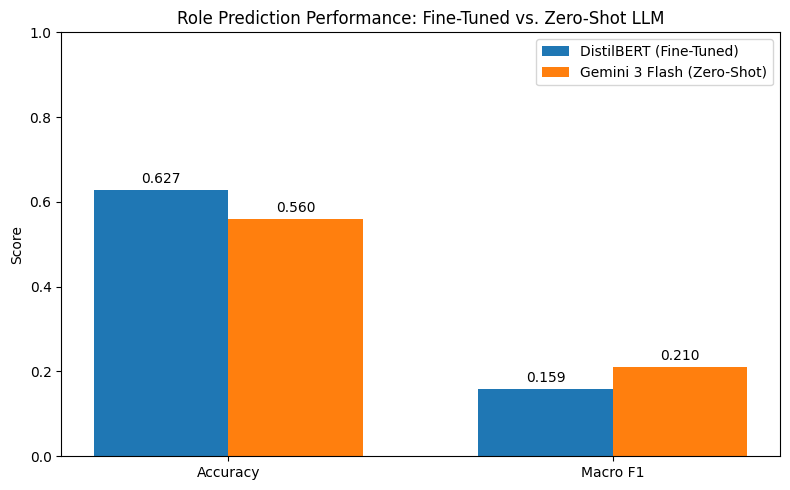

In [ ]:
#graph
import matplotlib.pyplot as plt
import numpy as np

gemini_accuracy = 0.56
gemini_macro_f1 = 0.21

distilbert_accuracy = 0.627
distilbert_macro_f1 = 0.159

labels = ['Accuracy', 'Macro F1']
distilbert_scores = [distilbert_accuracy, distilbert_macro_f1]
gemini_scores = [gemini_accuracy, gemini_macro_f1]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, distilbert_scores, width, label='DistilBERT (Fine-Tuned)', color='#1f77b4')
rects2 = ax.bar(x + width/2, gemini_scores, width, label='Gemini 3 Flash (Zero-Shot)', color='#ff7f0e')

ax.set_ylabel('Score')
ax.set_title('Role Prediction Performance: Fine-Tuned vs. Zero-Shot LLM')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.legend()

# Add the numbers on top of the bars
ax.bar_label(rects1, fmt='%.3f', padding=3)
ax.bar_label(rects2, fmt='%.3f', padding=3)

fig.tight_layout()
plt.savefig("baseline_comparison_chart.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd
import json

# Load  Business Unit test set
df_bu = pd.read_csv("outputs/metrics/predictions_business_unit.csv")

with open("llm_input_bu.jsonl", "w", encoding="utf-8") as f:
    for index, row in df_bu.iterrows():
        record = {
            "id": index,
            "text": row['text']
        }
        f.write(json.dumps(record) + "\n")

print("llm_input_bu.jsonl is ready!")

llm_input_bu.jsonl is ready!


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, f1_score

# load business unit ground truth
truth_df_bu = pd.read_csv("outputs/metrics/predictions_business_unit.csv")

baseline_df_bu = pd.read_csv("gemini_baseline_bu.csv")

# Merge them on the ID
merged_bu = truth_df_bu.merge(baseline_df_bu, left_index=True, right_on='id', how='inner')

y_true_bu = merged_bu['business_unit']
y_pred_bu = merged_bu['prediction_y']

# final metrics
accuracy_bu = accuracy_score(y_true_bu, y_pred_bu)
macro_f1_bu = f1_score(y_true_bu, y_pred_bu, average='macro')
micro_f1_bu = f1_score(y_true_bu, y_pred_bu, average='micro')

print(f"Gemini Zero-Shot Accuracy (Business Unit): {accuracy_bu:.4f}")
print(f"Gemini Zero-Shot Macro F1 (Business Unit): {macro_f1_bu:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_bu, y_pred_bu))

Gemini Zero-Shot Accuracy (Business Unit): 0.7392
Gemini Zero-Shot Macro F1 (Business Unit): 0.4831

Classification Report:
                          precision    recall  f1-score   support

Administrative Asisstant       0.00      0.00      0.00       137
Administrative Assistant       0.00      0.00      0.00         0
            Enron Online       0.45      0.61      0.52       333
        Legal Department       0.71      0.93      0.81       292
      Regulatory Affairs       0.68      0.72      0.70       347
    Risk Management Head       0.99      0.78      0.87      2342

                accuracy                           0.74      3451
               macro avg       0.47      0.51      0.48      3451
            weighted avg       0.84      0.74      0.78      3451



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

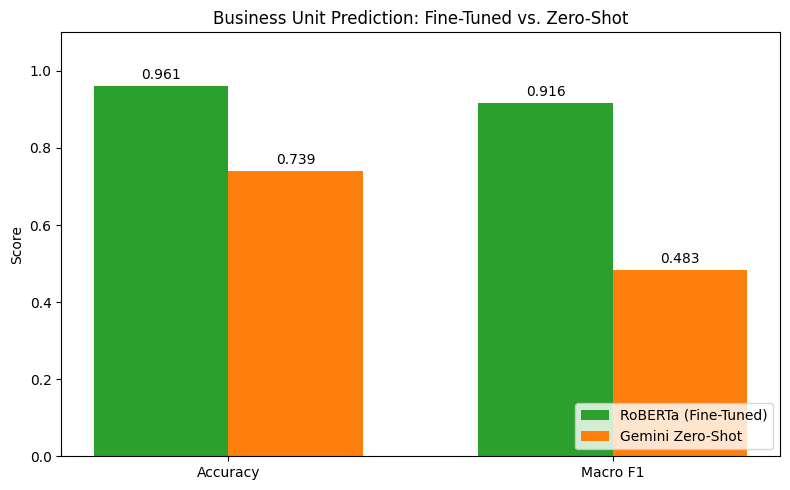

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# gemini baseline(business unit)
gemini_accuracy_bu = 0.739
gemini_macro_f1_bu = 0.483

#  RoBERTa (business unit)
roberta_accuracy_bu = 0.961
roberta_macro_f1_bu = 0.916

labels = ['Accuracy', 'Macro F1']
roberta_scores = [roberta_accuracy_bu, roberta_macro_f1_bu]
gemini_scores = [gemini_accuracy_bu, gemini_macro_f1_bu]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, roberta_scores, width, label='RoBERTa (Fine-Tuned)', color='#2ca02c')
rects2 = ax.bar(x + width/2, gemini_scores, width, label='Gemini Zero-Shot', color='#ff7f0e')

ax.set_ylabel('Score')
ax.set_title('Business Unit Prediction: Fine-Tuned vs. Zero-Shot')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')

ax.bar_label(rects1, fmt='%.3f', padding=3)
ax.bar_label(rects2, fmt='%.3f', padding=3)

fig.tight_layout()
plt.savefig("baseline_comparison_bu_chart.png", dpi=300)
plt.show()

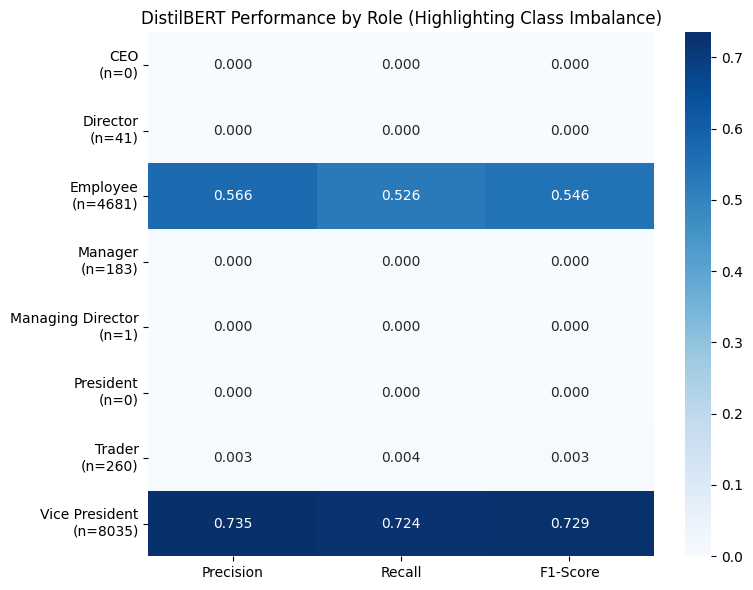

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

roles = ['CEO', 'Director', 'Employee', 'Manager', 'Managing Director', 'President', 'Trader', 'Vice President']
metrics_data = {
    'Precision': [0.000, 0.000, 0.566, 0.000, 0.000, 0.000, 0.003, 0.735],
    'Recall':    [0.000, 0.000, 0.526, 0.000, 0.000, 0.000, 0.004, 0.724],
    'F1-Score':  [0.000, 0.000, 0.546, 0.000, 0.000, 0.000, 0.003, 0.729]
}
support_values = [0, 41, 4681, 183, 1, 0, 260, 8035]

df_metrics = pd.DataFrame(metrics_data, index=roles)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_metrics, annot=True, cmap="Blues", fmt=".3f", cbar=True, ax=ax)

new_labels = [f"{role}\n(n={supp})" for role, supp in zip(roles, support_values)]
ax.set_yticklabels(new_labels, rotation=0)

plt.title("DistilBERT Performance by Role (Highlighting Class Imbalance)")
plt.tight_layout()

plt.savefig("class_imbalance_heatmap.png", dpi=300)
plt.show()

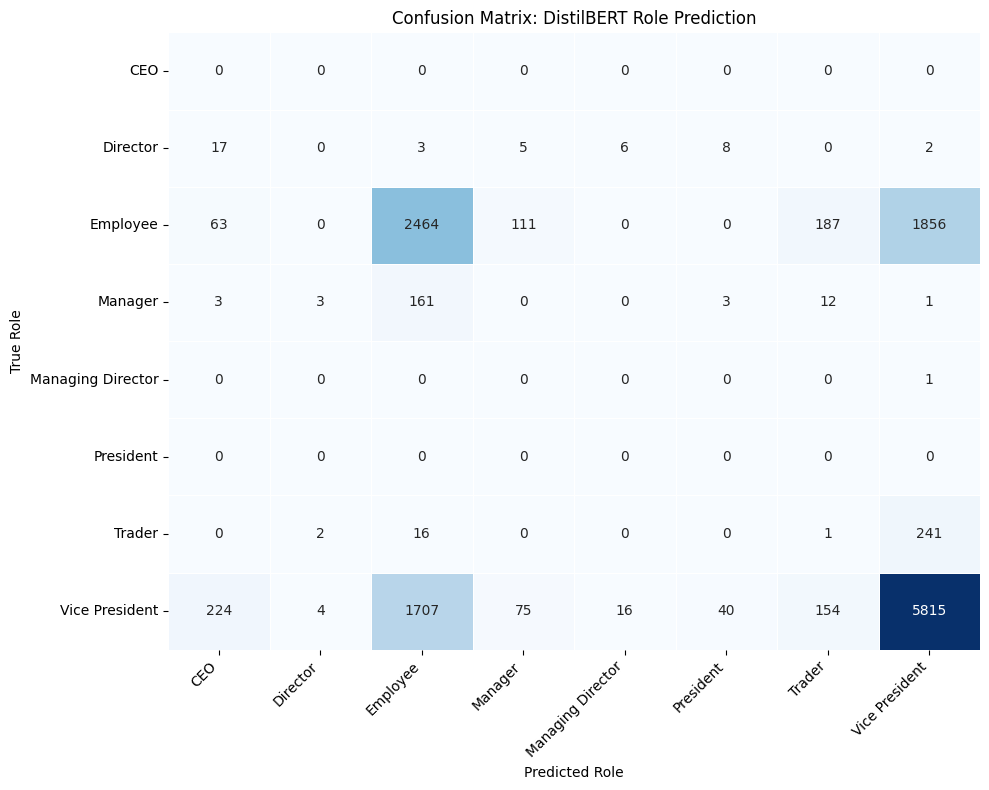

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

df = pd.read_csv("outputs/metrics/predictions_role.csv")

df = df.dropna(subset=['role', 'prediction'])

roles = [
    'CEO', 'Director', 'Employee', 'Manager',
    'Managing Director', 'President', 'Trader', 'Vice President'
]

cm = confusion_matrix(df['role'], df['prediction'], labels=roles)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=roles, yticklabels=roles,
            cbar=False, linewidths=.5)

plt.title('Confusion Matrix: DistilBERT Role Prediction')
plt.xlabel('Predicted Role')
plt.ylabel('True Role')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("confusion_matrix_role.png", dpi=300)
plt.show()

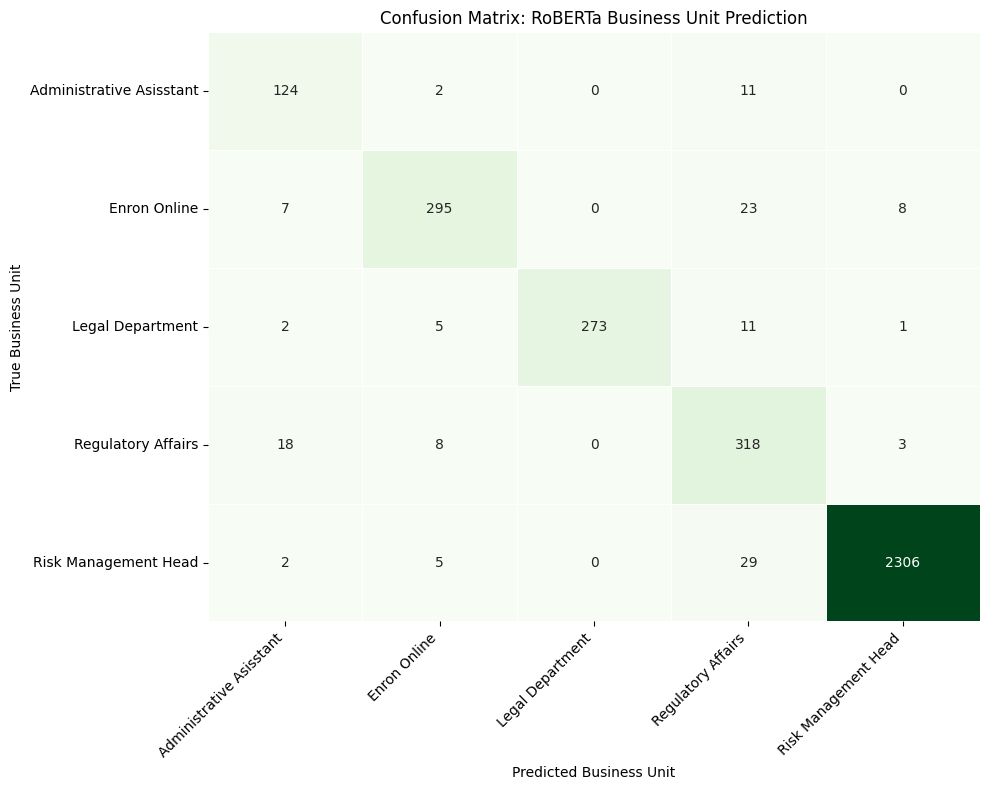

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

df_bu = pd.read_csv("outputs/metrics/predictions_business_unit.csv")

df_bu = df_bu.dropna(subset=['business_unit', 'prediction'])

business_units = [
    'Administrative Asisstant',
    'Enron Online',
    'Legal Department',
    'Regulatory Affairs',
    'Risk Management Head'
]

cm_bu = confusion_matrix(df_bu['business_unit'], df_bu['prediction'], labels=business_units)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_bu, annot=True, fmt='d', cmap='Greens',
            xticklabels=business_units, yticklabels=business_units,
            cbar=False, linewidths=.5)

plt.title('Confusion Matrix: RoBERTa Business Unit Prediction')
plt.xlabel('Predicted Business Unit')
plt.ylabel('True Business Unit')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("confusion_matrix_business_unit.png", dpi=300)
plt.show()

## Outputs

- Models: `outputs/models/`
- Metrics: `outputs/metrics/`
- Figures: `outputs/figures/`

To regenerate the standalone notebook from your repo after code changes, run from the project root:

`python notebooks/_generate_standalone_colab.py`
